In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_csv("Citas_Digital_Filtrado.csv")
df.columns = [c.strip() for c in df.columns]  # varias columnas venían con espacios al final
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   BDC                                       660 non-null    object 
 1   Fecha                                     75 non-null     object 
 2   Nombre Cliente                            655 non-null    object 
 3   Telefono                                  2 non-null      object 
 4   Estatus de Lead                           641 non-null    object 
 5   Potencial de compra                       602 non-null    object 
 6   PDM                                       675 non-null    float64
 7   SDC                                       674 non-null    float64
 8   Venta                                     671 non-null    float64
 9   Asesor Asignado                           644 non-null    object 
 10  ¿Por que no ha visitado la agencia?   

In [3]:
columnas_numericas = df.select_dtypes(include="number").columns.tolist()
columnas_texto = df.select_dtypes(include="object").columns.tolist()

print("Columnas numéricas:", columnas_numericas)
print("Columnas de texto / categóricas:", columnas_texto)


Columnas numéricas: ['PDM', 'SDC', 'Venta']
Columnas de texto / categóricas: ['BDC', 'Fecha', 'Nombre Cliente', 'Telefono', 'Estatus de Lead', 'Potencial de compra', 'Asesor Asignado', '¿Por que no ha visitado la agencia?', '¿Por que no hay solicitud de credito?', '¿Por que no hubo prueba de manejo ?', '¿Por que no hubo proceso wow?', '¿Por que se asigno antes de vistar piso?', 'Unnamed: 15']


In [4]:
df[columnas_numericas].describe()


,PDM,SDC,Venta
count,675.000000,674.000000,671.000000
mean,0.502222,0.399110,0.086438
std,0.597654,0.490079,0.281220
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000
max,9.000000,1.000000,1.000000


In [5]:
columnas_comentario = [
    "¿Por que no ha visitado la agencia?",
    "¿Por que no hay solicitud de credito?",
    "¿Por que no hubo prueba de manejo ?",
    "¿Por que no hubo proceso wow?",
    "¿Por que se asigno antes de vistar piso?",
    "Unnamed: 15",
]

comentario_combinado = df[columnas_comentario].apply(
    lambda fila: " ".join(str(v) for v in fila if pd.notna(v)), axis=1
)
comentario_combinado = comentario_combinado.replace("", np.nan)

longitud_comentario = comentario_combinado.dropna().str.len()

print(f"Comentarios combinados disponibles: {longitud_comentario.count()} de {len(df)} filas")
longitud_comentario.describe()


Comentarios combinados disponibles: 493 de 676 filas


,0
count,493.000000
mean,95.340771
std,55.144355
min,12.000000
25%,68.000000
50%,110.000000
75%,111.000000
max,379.000000


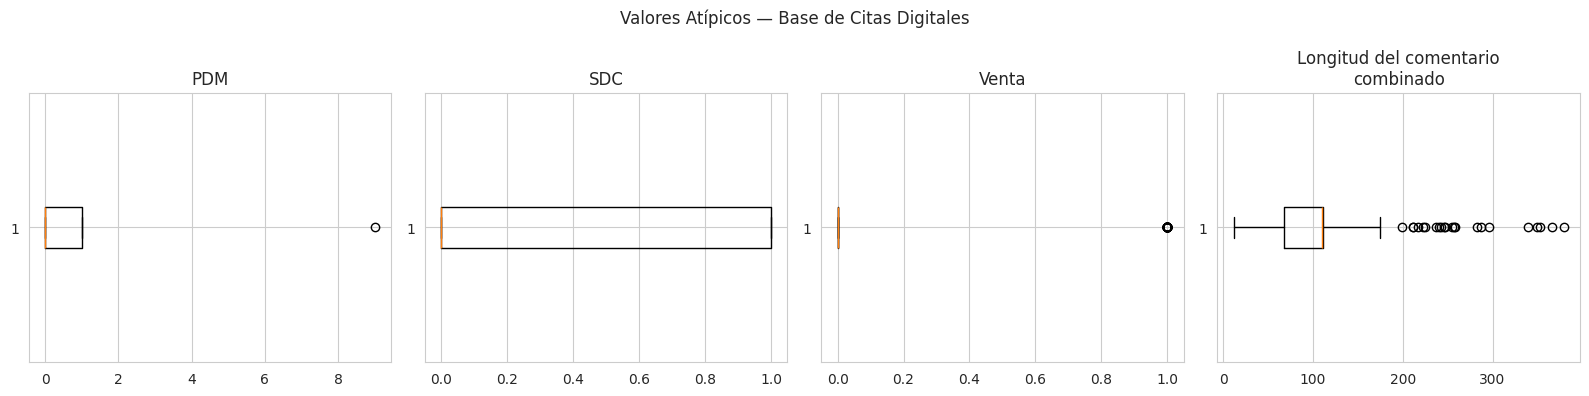

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].boxplot(df["PDM"].dropna(), vert=False)
axes[0].set_title("PDM")

axes[1].boxplot(df["SDC"].dropna(), vert=False)
axes[1].set_title("SDC")

axes[2].boxplot(df["Venta"].dropna(), vert=False)
axes[2].set_title("Venta")

axes[3].boxplot(longitud_comentario, vert=False)
axes[3].set_title("Longitud del comentario\ncombinado")

plt.suptitle("Valores Atípicos — Base de Citas Digitales")
plt.tight_layout()
plt.show()


Método de desviación estándar (±3σ)

In [7]:
def limites_std(serie, n_sigma=3):
    media, sd = serie.mean(), serie.std()
    return media - n_sigma * sd, media + n_sigma * sd

variables = {
    "PDM": df["PDM"].dropna(),
    "SDC": df["SDC"].dropna(),
    "Venta": df["Venta"].dropna(),
    "Longitud del comentario": longitud_comentario,
}

for nombre, serie in variables.items():
    li, ls = limites_std(serie)
    atipicos = serie[(serie < li) | (serie > ls)]
    print(f"--- {nombre} ---")
    print(f"Límite inferior permitido: {li:.2f}  |  Límite superior permitido: {ls:.2f}")
    print(f"Valores atípicos encontrados: {len(atipicos)}")
    print()


--- PDM ---
Límite inferior permitido: -1.29  |  Límite superior permitido: 2.30
Valores atípicos encontrados: 1

--- SDC ---
Límite inferior permitido: -1.07  |  Límite superior permitido: 1.87
Valores atípicos encontrados: 0

--- Venta ---
Límite inferior permitido: -0.76  |  Límite superior permitido: 0.93
Valores atípicos encontrados: 58

--- Longitud del comentario ---
Límite inferior permitido: -70.09  |  Límite superior permitido: 260.77
Valores atípicos encontrados: 8



Método de rango intercuartílico (IQR)

In [8]:
def limites_iqr(serie, factor=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

resultados_iqr = {}
for nombre, serie in variables.items():
    li, ls = limites_iqr(serie)
    atipicos = serie[(serie < li) | (serie > ls)]
    resultados_iqr[nombre] = atipicos
    print(f"--- {nombre} ---")
    print(f"Límite inferior permitido: {li:.2f}  |  Límite superior permitido: {ls:.2f}")
    print(f"Valores atípicos encontrados: {len(atipicos)}")
    print()


--- PDM ---
Límite inferior permitido: -1.50  |  Límite superior permitido: 2.50
Valores atípicos encontrados: 1

--- SDC ---
Límite inferior permitido: -1.50  |  Límite superior permitido: 2.50
Valores atípicos encontrados: 0

--- Venta ---
Límite inferior permitido: 0.00  |  Límite superior permitido: 0.00
Valores atípicos encontrados: 58

--- Longitud del comentario ---
Límite inferior permitido: 3.50  |  Límite superior permitido: 175.50
Valores atípicos encontrados: 22



En los resultados, PDM presenta 1 valor atípico (`PDM = 9`), que probablemente es un error de captura porque debería ser 0 o 1, por lo que se reporta para corregirlo manualmente. SDC no presenta valores atípicos, mientras que en Venta aparecen 58, pero corresponden a todas las ventas (`Venta = 1`), así que aunque estadísticamente parecen extremos, representan resultados reales del negocio y no deben eliminarse.

Por otro lado, en la longitud del comentario se detectan algunos comentarios inusualmente largos. Estos se consideran casos para revisar la calidad de captura, pero no necesariamente significan que exista un error.


In [9]:
fila_pdm_atipica = df[df["PDM"] == 9]
comentarios_largos = comentario_combinado[
    longitud_comentario.reindex(comentario_combinado.index) > limites_iqr(longitud_comentario)[1]
]

print("Registro con PDM fuera de rango (0/1) — para revisión manual, no se sobrescribe:")
display(fila_pdm_atipica)
print()
print(f"Comentarios inusualmente largos ({len(comentarios_largos)}) — para revisión de calidad:")
comentarios_largos


Registro con PDM fuera de rango (0/1) — para revisión manual, no se sobrescribe:


,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
32,Saul,NaN,13,Toño,11,Ventas,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Comentarios inusualmente largos (22) — para revisión de calidad:


,0
0,"Ya visito la Agencia el dia jueves 17, intere..."
1,Ya visito la Agencia el dia 3 de abril Por q...
2,Ya visito la agencia el dia 21 de abril Firmo...
3,El cliente vive en Tabasco Villahermosa Sera c...
4,"Visito la agencia el mes pasado, y nos visita ..."
5,Visito la agencia el dia 13 de abril Si hubo s...
6,"Se programo la visita dos dias, pero nunca asi..."
7,Visito la agencia el dia 13 de abril Se le com...
8,No ha visitado la agencia por temas de trabajo...
9,Se le complicaba asitir sin embargo se le llev...


No se reemplazo ni elimino los valores atípicos, porque pueden representar información importante. En `PDM`, el valor atípico es probablemente un error, pero no puedo saber si debería ser 0 o 1, así que prefiero marcarlo para corrección manual. En `Venta`, los valores `1` representan ventas reales, por lo que eliminarlos quitaría información importante. Finalmente, un comentario largo no necesariamente es un error, ya que puede ser un seguimiento detallado, así que solo se deja como caso para revisar.



In [10]:
df_exportar = df.copy()
df_exportar["Longitud_comentario_combinado"] = longitud_comentario.reindex(df_exportar.index)

RUTA_SALIDA = "Citas_Digital_analizada.xlsx"
df_exportar.to_excel(RUTA_SALIDA, index=False)
print(f"Base exportada a: {RUTA_SALIDA}")


Base exportada a: Citas_Digital_analizada.xlsx


In [ ]:
# Si el notebook se ejecuta en Google Colab, esta celda descarga el archivo al equipo.
# En un entorno local/Jupyter normal, el archivo ya quedó guardado en la ruta de arriba.
try:
    from google.colab import files
    files.download(RUTA_SALIDA)
except ImportError:
    print("No estás en Google Colab: el archivo ya está guardado localmente en", RUTA_SALIDA)


No estás en Google Colab: el archivo ya está guardado localmente en Citas_Digital_analizada.xlsx
